In [ ]:
import re
from collections import defaultdict
import sys
sys.path.append('..')
from utils.parser import str_to_triplet
from kg_connector.kg_connector import KGConnector
from embeddings.embedder import Embedder
from typing import Optional
import matplotlib.pyplot as plt
import networkx as nx
from math import ceil

class GroupNDecompose:

    def __init__(self, embedder: Optional[Embedder] = None, kg_connector: Optional[KGConnector] = None):
        self.embedder : Embedder = Embedder() if embedder is None else embedder
        self.kg_connector     : KGConnector      = KGConnector() if kg_connector is None else kg_connector


    def is_unknown(self, entity: str) -> bool:
        if entity is None:
            raise ValueError("Entity cannot be None")
        if not isinstance(entity, str):
            raise TypeError("Entity must be a string")
        if not entity:
            raise ValueError("Entity cannot be an empty string")

        return entity.startswith("unknown_")

    def group_n_decompose(self, triplets: list[str]) -> dict:
        """
        Group and decompose triplets based on entity types.
        """
        parsed : list[dict[str, str]] = []
        for triplet in triplets:
            head, relation, tail = str_to_triplet(triplet)
            parsed.append({
                "head"    : head,
                "relation": relation,
                "tail"    : tail,
            })

        # Normalize relations
        parsed = self.normalize_relation(parsed)

        # Build KG adjacency
        kg_ref: dict[str, dict[str, list]] = self.build_kg_adjacency(parsed)

        completed = []
        incompleted = []
        decomposed_triplets = []

        # Decompose groups based on entity types
        if kg_ref is not None:
            null_relation_counter = 0
            unknown_counter = 999  # sinh unknown mới
            for t in parsed:
                e1, r, e2 = t["head"], t["relation"], t["tail"]
                if self.is_unknown(e1) or self.is_unknown(e2):
                    # both unknown, keep as is
                    decomposed_triplets.append(t)
                    continue

                # Check if e1, e2 connected by relation r in KG
                e1_rels = kg_ref.get(e1, {})
                rel_entities = e1_rels.get(r, [])
                is_e2_exist = e2 in rel_entities
                if not is_e2_exist:
                    unknown_counter += 2

                    # tách thành 2 incomplete triplets
                    t1 = {"head": e1, "relation": f"null_relation_{null_relation_counter}", "tail": f"unknown_{unknown_counter}"}
                    t2 = {"head": f"unknown_{unknown_counter + 1}", "relation": f"null_relation_{null_relation_counter + 1}", "tail": e2}

                    decomposed_triplets.append(t1)
                    decomposed_triplets.append(t2)
                else:
                    decomposed_triplets.append(t)
        else:
            decomposed_triplets = completed[:]  # giữ nguyên nếu không check KG

        # Separate completed and incompleted triplets
        for triplet in decomposed_triplets:
            if self.is_unknown(triplet["head"]) or self.is_unknown(triplet["tail"]):
                incompleted.append(triplet)
            else:
                completed.append(triplet)

        # Grouping incompleted triplets by unknown entity
        groups = defaultdict(list)
        for t in incompleted:
            if self.is_unknown(t["head"]):
                groups[t["head"]].append(("head", t))
            elif self.is_unknown(t["tail"]):
                groups[t["tail"]].append(("tail", t))

        grouped = {}
        for unk, arr in groups.items():
            explicit_entities   = [] # explicit entities in the group that linked to unknown_
            relations           = []

            for pos, t in arr:
                if pos == "head":
                    explicit_entities.append(t["tail"])
                    relations.append(t["relation"])
                elif pos == "tail":
                    explicit_entities.append(t["head"])
                    relations.append(t["relation"])

            grouped[unk] = {
                "unknown": unk,
                "explicit_entities": explicit_entities,
                "relations": relations,
                "raw_triplets": [x[1] for x in arr],
            }

        return {
            "complete_triplets": completed,
            "incomplete_groups": grouped,
        }

    def normalize_relation(self, triplet_dicts: list[dict[str, str]]):
        """
        Normalize relations in triplet dictionaries using RelationEmbedder.
        """
        for triplet in triplet_dicts:
            raw_relation = triplet["relation"]
            matched_relation, score = self.embedder.match_relation(raw_relation, top_k=1)[0]
            triplet["relation"] = matched_relation
        return triplet_dicts

    def build_kg_adjacency(self, triplet_dicts: list[dict[str, str]]) -> dict[str, dict[str, list]]:
        """
        Build KG adjacency list from triplet dictionaries.
        """
        explicit_entities = set()
        for triplet in triplet_dicts:
            if not self.is_unknown(triplet["head"]):
                explicit_entities.add(triplet["head"])
            if not self.is_unknown(triplet["tail"]):
                explicit_entities.add(triplet["tail"])
        explicit_entities = list(explicit_entities)

        relations = [triplet["relation"] for triplet in triplet_dicts]

        adjacency_list = self.kg_connector.build_local_adj(explicit_entities, relations)
        return adjacency_list



    def visualize_groups(self, grouped_decomposed: dict):
        """
        Visualize grouped & decomposed triplets.

        - Each group (unknown node) is shown on its own subplot.
        - Complete triplets are shown with GREEN nodes.
        - All others (groups + decomposed) use BLUE nodes.
        - Relation names are shown on arrows.
        """

        complete     = grouped_decomposed.get("complete_triplets", [])
        groups       = grouped_decomposed.get("incomplete_groups", {})

        # Prepare list of (title, triplets, is_complete_flag)
        plots = []

        if complete:
            plots.append(("Complete Triplets", complete, True))

        for unk, g in groups.items():
            plots.append((f"Group: {unk}", g["raw_triplets"], False))

        num_plots = len(plots)
        cols = 2
        rows = ceil(num_plots / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
        axes = axes.flatten()

        for ax, (title, triplets, is_complete) in zip(axes, plots):
            G = nx.DiGraph()

            # Add edges
            for t in triplets:
                h = t["head"]
                r = t["relation"]
                v = t["tail"]
                G.add_edge(h, v, label=r)

            pos = nx.spring_layout(G, seed=42)

            # Node colors:
            if is_complete:
                node_color = "#9AF5A2"    # green
            else:
                node_color = "#CDE5FF"    # light blue

            # Draw graph
            nx.draw(
                G, pos,
                ax=ax,
                with_labels=True,
                arrows=True,
                node_size=2200,
                node_color=node_color,
                font_size=10
            )

            # Relation labels
            edge_labels = {(h, v): data["label"] for h, v, data in G.edges(data=True)}
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=9)

            ax.set_title(title, fontsize=14)
            ax.axis("off")

        # Hide unused subplots if any
        for i in range(len(plots), len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()


Loaded 527 relations and their embeddings from D:\\claimpkg\\claimpkg-clone\\src\\resources\\embeddings.
grouped_decomposed: {'complete_triplets': [{'head': 'Pho', 'relation': 'region', 'tail': 'Hanoi'}], 'incomplete_groups': {'unknown_1001': {'unknown': 'unknown_1001', 'explicit_entities': ['Hanoi'], 'relations': ['null_relation_0'], 'raw_triplets': [{'head': 'Hanoi', 'relation': 'null_relation_0', 'tail': 'unknown_1001'}]}, 'unknown_1002': {'unknown': 'unknown_1002', 'explicit_entities': ['Europe'], 'relations': ['null_relation_1'], 'raw_triplets': [{'head': 'unknown_1002', 'relation': 'null_relation_1', 'tail': 'Europe'}]}, 'unknown_0': {'unknown': 'unknown_0', 'explicit_entities': ['Pho', 'Mì Quảng', 'Meat and potato pie'], 'relations': ['ingredient', 'ingredient', 'ingredient'], 'raw_triplets': [{'head': 'unknown_0', 'relation': 'ingredient', 'tail': 'Pho'}, {'head': 'unknown_0', 'relation': 'ingredient', 'tail': 'Mì Quảng'}, {'head': 'unknown_0', 'relation': 'ingredient', 'tail':

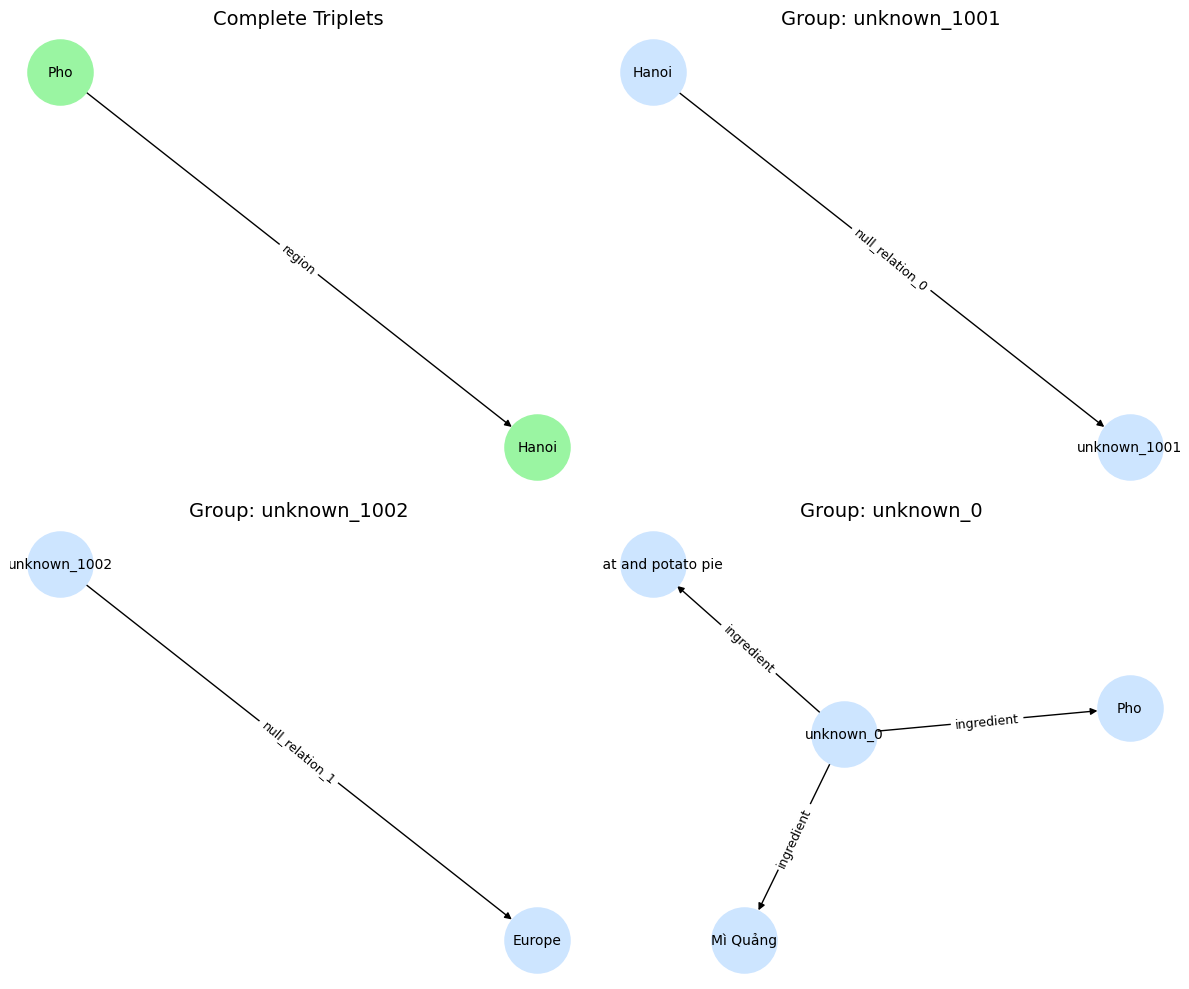

In [5]:
gnd = GroupNDecompose()

claim = "Pho is a is popular in the region of Hanoi, that in the center of West Europe. This contains an ingredient that is both used in Mì Quảng and Meat and potato pie."
non_normalized_triplets = [
    "<e>Pho</e>|| popular_in_region || <e>Hanoi</e>",
    "<e>Hanoi</e>|| in_center_of_continent || <e>Europe</e>",
    "<e>unknown_0</e>|| has_ingredient || <e>Pho</e>",
    "<e>unknown_0</e>|| has_ingredient || <e>Mì Quảng</e>",
    "<e>unknown_0</e>|| has_ingredient || <e>Meat and potato pie</e>"
]
normalized_triplets = [
    "<e>Pho</e>|| region || <e>Hanoi</e>",
    "<e>Hanoi</e>|| locationCountry || <e>Europe</e>",
    "<e>unknown_0</e>|| ingredient || <e>Pho</e>",
    "<e>unknown_0</e>|| ingredient || <e>Mì Quảng</e>",
    "<e>unknown_0</e>|| ingredient || <e>Meat and potato pie</e>"
]
triplet_dicts = [
    {"head": "Pho", "relation": "popular_in_region", "tail": "Hanoi"},
    {"head": "Hanoi", "relation": "in_center_of_continent", "tail": "Europe"},
    {"head": "unknown_0", "relation": "has_ingredient", "tail": "Pho"},
    {"head": "unknown_0", "relation": "has_ingredient", "tail": "Mì Quảng"},
    {"head": "unknown_0", "relation": "has_ingredient", "tail": "Meat and potato pie"},
]
normalized_triplets_dict = [
    {'head': 'Pho', 'relation': 'region', 'tail': 'Hanoi'},
    {'head': 'Hanoi', 'relation': 'locationCountry', 'tail': 'Europe'},
    {'head': 'unknown_0', 'relation': 'ingredient', 'tail': 'Pho'},
    {'head': 'unknown_0', 'relation': 'ingredient', 'tail': 'Mì Quảng'},
    {'head': 'unknown_0', 'relation': 'ingredient', 'tail': 'Meat and potato pie'}
]
# normalized_triplets = gnd.normalize_relation(triplet_dicts)
# print(f"normalized_triplets: {normalized_triplets}")
# kg_adj = gnd.build_kg_adjacency(normalized_triplets_dict)
# print(f"kg_adj: {kg_adj}")
# kg_adj = {'Europe': {}, 'Pho': {'region': ['Hanoi', 'Nam Định Province'], 'ingredient': ['Beef', 'Chicken (food)', 'Rice noodles', 'Beef']}, 'Hanoi': {}, 'Meat and potato pie': {'ingredient': ['Beef']}, 'Mì Quảng': {'region': ['Quảng Nam Province'], 'ingredient': ['Pork', 'Beef', 'Rice noodles', 'Shrimp', 'Turmeric', 'Chicken (food)', 'Beef']}}

grouped_decomposed = gnd.group_n_decompose(non_normalized_triplets)
print(f"grouped_decomposed: {grouped_decomposed}")

gnd.visualize_groups(grouped_decomposed)
# OK